<a href="https://colab.research.google.com/github/PrantoSarkar/Pranta-Kumar-Sarkar_AcademicCV/blob/main/smart_grid_modify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import io
from google.colab import files
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import GridSearchCV
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.base import BaseEstimator
from sklearn.base import ClassifierMixin
from sklearn.preprocessing import LabelEncoder
import six
import sys
sys.modules['sklearn.externals.six'] = six
from sklearn.externals import six
from sklearn.base import clone
from sklearn.pipeline import _name_estimators


In [ ]:
uploaded = files.upload()

Saving True.csv to True.csv


In [ ]:

all_data1 = pd.read_csv(io.BytesIO(uploaded['smart_grid_stability.csv']))


In [ ]:
all_data1['stabf'].replace(['unstable', 'stable'],
                        [0, 1], inplace=True)

In [ ]:
all_data1.head

<bound method NDFrame.head of            tau1      tau2      tau3  ...        g4      stab  stabf
0      2.959060  3.079885  8.381025  ...  0.958034  0.055347      0
1      9.304097  4.902524  3.047541  ...  0.781760 -0.005957      1
2      8.971707  8.848428  3.046479  ...  0.109853  0.003471      0
3      0.716415  7.669600  4.486641  ...  0.362718  0.028871      0
4      3.134112  7.608772  4.943759  ...  0.820923  0.049860      0
...         ...       ...       ...  ...       ...       ...    ...
59995  2.930406  2.376523  9.487627  ...  0.608385  0.023892      0
59996  3.392299  2.954947  1.274827  ...  0.366120 -0.025803      1
59997  2.364034  8.776391  2.842030  ...  0.145984 -0.031810      1
59998  9.631511  2.757071  3.994398  ...  0.818391  0.037789      0
59999  6.530527  4.349695  6.781790  ...  0.942631  0.045263      0

[60000 rows x 14 columns]>

In [ ]:
correlations = all_data1.corr()
print(correlations)

           tau1      tau2      tau3  ...        g4      stab     stabf
tau1   1.000000 -0.002550 -0.002550  ...  0.006522  0.275761 -0.234898
tau2  -0.002550  1.000000  0.005554  ...  0.002102  0.283417 -0.241049
tau3  -0.002550  0.005554  1.000000  ...  0.002102  0.283417 -0.241049
tau4  -0.002550  0.005554  0.005554  ...  0.009865  0.283417 -0.241049
p1     0.027183  0.003004  0.003004  ...  0.000341  0.010278 -0.009938
p2    -0.015739 -0.004473 -0.000372  ...  0.000774 -0.005951  0.005754
p3    -0.015739 -0.000372 -0.004473  ...  0.000774 -0.005951  0.005754
p4    -0.015739 -0.000372 -0.000372  ... -0.002141 -0.005951  0.005754
g1     0.010521 -0.005832 -0.005832  ...  0.004718  0.282774 -0.197664
g2     0.006522  0.009865  0.002102  ... -0.006939  0.293684 -0.218015
g3     0.006522  0.002102  0.009865  ... -0.006939  0.293684 -0.218015
g4     0.006522  0.002102  0.002102  ...  1.000000  0.293684 -0.218015
stab   0.275761  0.283417  0.283417  ...  0.293684  1.000000 -0.826959
stabf 

In [ ]:
all_data = all_data.sample(frac = 1)   # Shuffle the data for better results
all_data.describe(include = 'all')

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unstable
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38280
mean,5.250000,5.250001,5.250001,5.250001,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731,NaN
std,2.742434,2.742437,2.742437,2.742437,0.752129,0.433017,0.433017,0.433017,0.274244,0.274243,0.274243,0.274243,0.036917,NaN
min,0.500793,0.500141,0.500141,0.500141,1.582590,-1.999945,-1.999945,-1.999945,0.050009,0.050028,0.050028,0.050028,-0.080760,NaN
25%,2.874892,2.875011,2.875011,2.875011,3.218300,-1.624997,-1.624997,-1.624997,0.287521,0.287497,0.287497,0.287497,-0.015557,NaN
50%,5.250004,5.249981,5.249981,5.249981,3.751025,-1.249996,-1.249996,-1.249996,0.525009,0.525007,0.525007,0.525007,0.017142,NaN
75%,7.624690,7.624896,7.624896,7.624896,4.282420,-0.874993,-0.874993,-0.874993,0.762435,0.762490,0.762490,0.762490,0.044878,NaN


In [ ]:
# Creating dummy variable for categorical features to include in model training
all_data = pd.get_dummies(all_data, columns = ['stabf'], drop_first = True)

In [ ]:
all_data.head

<bound method NDFrame.head of            tau1      tau2      tau3  ...        g4      stab  stabf_unstable
51087  5.167021  9.166753  1.403811  ...  0.356747  0.026528               1
22586  4.159878  5.938740  4.047045  ...  0.877390  0.039934               1
42986  3.515730  4.644664  3.742466  ...  0.975816  0.086354               1
4611   1.827879  5.451418  9.745066  ...  0.793450  0.041107               1
33021  2.004307  5.111265  3.040187  ...  0.676788 -0.017697               0
...         ...       ...       ...  ...       ...       ...             ...
46665  5.593826  6.072063  5.347266  ...  0.112953  0.034466               1
21946  8.897892  5.491228  8.180958  ...  0.674751  0.086224               1
44665  3.343166  9.514237  9.016328  ...  0.983020  0.043296               1
12699  1.292820  2.174072  5.631026  ...  0.685749  0.000608               1
6960   1.518184  3.823195  5.756481  ...  0.209707  0.020289               1

[60000 rows x 14 columns]>

In [ ]:
X_data, Y_data = all_data.drop(columns=['stab', 'stabf_unstable']), all_data['stabf_unstable']

In [ ]:
Y_data.head

<bound method NDFrame.head of 51087    1
22586    1
42986    1
4611     1
33021    0
        ..
46665    1
21946    1
44665    1
12699    1
6960     1
Name: stabf_unstable, Length: 60000, dtype: uint8>

In [ ]:
# Normalize
X_data_norm = X_data.copy()

# Normalization of input features are very helpful in increasing the performance of model.
# Normalization has also been found to increase efficiency of a model while training.
for column in X_data_norm.columns:
    X_data_norm[column] = (X_data_norm[column] - X_data_norm[column].mean()) * 1.0 / X_data_norm[column].std()

X_data_norm.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
count,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04
mean,-2.710843e-15,1.336988e-14,7.202437e-15,-1.217964e-14,-2.925618e-14,4.465099e-14,5.651771e-14,5.391136e-14,-3.909436e-14,1.567295e-15,-9.409469e-15,7.576236e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.731749e+00,-1.731985e+00,-1.731985e+00,-1.731985e+00,-2.881701e+00,-1.731906e+00,-1.731906e+00,-1.731906e+00,-1.731999e+00,-1.731935e+00,-1.731935e+00,-1.731935e+00
25%,-8.660585e-01,-8.660143e-01,-8.660143e-01,-8.660143e-01,-7.069270e-01,-8.660104e-01,-8.660104e-01,-8.660104e-01,-8.659381e-01,-8.660323e-01,-8.660323e-01,-8.660323e-01
50%,1.437158e-06,-7.028671e-06,-7.028671e-06,-7.028671e-06,1.363436e-03,8.877925e-06,8.877925e-06,8.877925e-06,3.412648e-05,2.434658e-05,2.434658e-05,2.434658e-05
75%,8.659059e-01,8.659801e-01,8.659801e-01,8.659801e-01,7.078844e-01,8.660332e-01,8.660332e-01,8.660332e-01,8.657800e-01,8.659828e-01,8.659828e-01,8.659828e-01
max,1.731845e+00,1.731976e+00,1.731976e+00,1.731976e+00,2.811245e+00,1.731977e+00,1.731977e+00,1.731977e+00,1.731805e+00,1.731971e+00,1.731971e+00,1.731971e+00


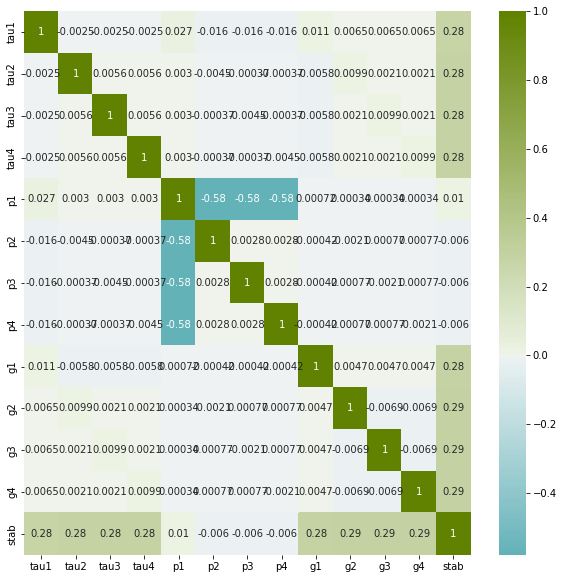

In [ ]:
# Correlation matrix helps us to identify features that are more important then the others.
corr_data = all_data.corr()
fig, ax = plt.subplots(figsize = (10, 10))
color_map = sns.diverging_palette(204, 106, s = 100, as_cmap=True)
sns.heatmap(corr_data.drop(columns=['stabf_unstable'], index=['stabf_unstable']), cmap=color_map, annot=True, ax = ax, center=0.00000)
plt.show()
del corr_data

In [ ]:
print(X_data_norm.shape, "\n", Y_data.shape)

(60000, 12) 
 (60000,)


In [ ]:
pd.Series(Y_data).value_counts()

1    38280
0    21720
Name: stabf_unstable, dtype: int64

In [ ]:
X_data_norm.head

<bound method NDFrame.head of            tau1      tau2      tau3  ...        g2        g3        g4
51087 -0.030257  1.428201 -1.402471  ...  1.256858  1.432173 -0.613519
22586 -0.397502  0.251142 -0.438645  ...  0.568004 -1.685207  1.284951
42986 -0.632384 -0.220729 -0.549706  ...  1.004404  0.210374  1.643853
4611  -1.247841  0.073445  1.639077  ... -0.994568  1.053756  0.978876
33021 -1.183508 -0.050588 -0.805785  ... -0.214288  0.627395  0.553480
...         ...       ...       ...  ...       ...       ...       ...
46665  0.125373  0.299756  0.035467  ...  1.317207 -1.728295 -1.502488
21946  1.330166  0.087961  1.068742  ...  0.797306  0.971169  0.546049
44665 -0.695307  1.554908  1.373351  ... -0.824244  0.602392  1.670122
12699 -1.442944 -1.121604  0.138937  ... -1.646267  0.569648  0.586155
6960  -1.360768 -0.520269  0.184683  ... -0.189037  1.364814 -1.149685

[60000 rows x 12 columns]>

In [ ]:
Y_data.head(20)

51087    1
22586    1
42986    1
4611     1
33021    0
56454    0
22315    0
31133    0
6669     1
41291    0
15575    1
51265    1
46032    1
40527    1
8462     1
2459     1
27370    1
52920    0
22387    1
34628    1
Name: stabf_unstable, dtype: uint8

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_data_norm, Y_data, train_size=0.8, random_state=42)

In [ ]:
pd.Series(Y_test).value_counts()

1    7653
0    4347
Name: stabf_unstable, dtype: int64

In [ ]:
pd.Series(Y_train).value_counts()

1    30623
0    17377
Name: stabf_unstable, dtype: int64

In [ ]:
def preprocess_inputs(df, task='classification'):
    df = df.copy()

    if task == 'classification':
        df = df.drop('stab', axis=1)

        y = df['stabf'].copy()
        X = df.drop('stabf', axis=1).copy()

    elif task == 'regression':
        df = df.drop('stabf', axis=1)

        y = df['stab'].copy()
        X = df.drop('stab', axis=1).copy()

    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=1)

    return X_train, X_test, y_train, y_test

In [ ]:
X_train, X_test, y_train, y_test = preprocess_inputs(all_data1, task='classification')

In [ ]:
from xgboost import XGBClassifier, XGBRegressor
clf = XGBClassifier()
clf.fit(X_train, y_train)
print("Classifier trained.")
print("Classification Test Accuracy: {:.2f}%".format(clf.score(X_test, y_test) * 100))

Classifier trained.
Classification Test Accuracy: 92.63%


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda= LDA(n_components=1)
X_train_lda=lda.fit_transform(X_train,Y_train)
X_test_lda=lda.transform(X_test)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
GBC = GradientBoostingClassifier(random_state=0)
GBC.fit(X_train_lda,Y_train)
pred_gbc = GBC.predict(X_test_lda)
from sklearn.metrics import accuracy_score as score
print('Test Accuracy')
print(score(Y_test,pred_gbc)*100)

Test Accuracy
81.65


In [ ]:
# 1. SVM

clf_1=SVC(C=0.001, kernel='linear', random_state=7, probability=True)

In [ ]:
clf_1.fit(X_train_lda,Y_train)
y_pred=clf_1.predict(X_test_lda)

In [ ]:
#accuracy in test data
from sklearn.metrics import accuracy_score as score
print('Test Accuracy')
print(score(Y_test,y_pred)*100)

Test Accuracy
81.325


In [ ]:
##precision, recall, F1 & AUC Score
from sklearn.metrics import precision_score, recall_score
Precision = precision_score(Y_test,y_pred)
Recall = recall_score(Y_test,y_pred)
print('Recall = ',Recall)
print('Precision = ',Precision)
from sklearn.metrics import f1_score
f1 = f1_score(Y_test,y_pred)
print('F1 = ',f1)
#AUC score
from sklearn.metrics import roc_auc_score
AUC = roc_auc_score(Y_test,y_pred)
print('AUC = ', AUC)

Recall =  0.7959664745940283
Precision =  0.7999473545669913
F1 =  0.7979519495864513
AUC =  0.7989733363069152


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
prediction = clf_1.predict(X_test_lda)
labels = ['0', '1']
cm=confusion_matrix(Y_test,prediction)

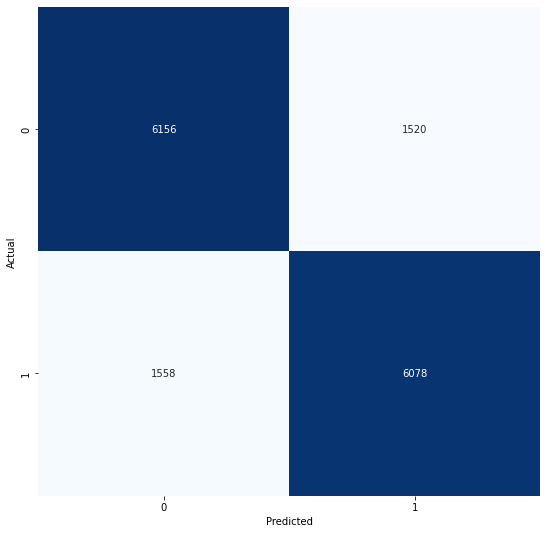

In [ ]:
import seaborn as sns
plt.figure(figsize=(9,9))
sns.heatmap(cm, cbar=False, xticklabels=labels, yticklabels=labels, fmt='d', annot=True, cmap=plt.cm.Blues)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Confusion Matrix.png')
plt.show()

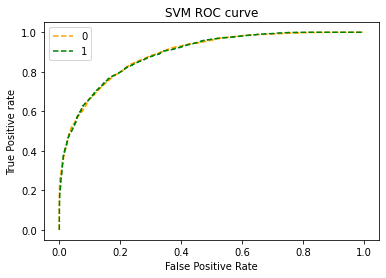

In [ ]:
result_table = pd.DataFrame(columns=['classifiers', 'fpr','tpr','auc'])
y_pred_proba=clf_1.predict_proba(X_test_lda)

fpr = {}
tpr = {}
thresh ={}

n_class = 2

for i in range(n_class):
    fpr[i], tpr[i], thresh[i] = roc_curve(Y_test, y_pred_proba[:,i], pos_label=i)

# plotting
plt.plot(fpr[0], tpr[0], linestyle='--',color='orange', label='0')
plt.plot(fpr[1], tpr[1], linestyle='--',color='green', label='1')
plt.title('SVM ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.savefig('Binaryclass ROC',dpi=300);

In [ ]:
# 2. Decesion Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
clf_2 = tree.DecisionTreeClassifier(criterion='gini', max_depth=5,  random_state=1)

In [ ]:
clf_2.fit(X_train_lda,Y_train)
y_pred=clf_2.predict(X_test_lda)

In [ ]:
#accuracy in test data
from sklearn.metrics import accuracy_score as score
print('Accuracy')
print(score(Y_test,y_pred)*100)

Accuracy
80.32262277951932


In [ ]:
##precision & recall
from sklearn.metrics import precision_score, recall_score
Precision = precision_score(Y_test,y_pred)
Recall = recall_score(Y_test,y_pred)
print('Recall = ',Recall)
print('Precision = ',Precision)
from sklearn.metrics import f1_score
f1 = f1_score(Y_test,y_pred)
print('F1 = ',f1)
#AUC score
from sklearn.metrics import roc_auc_score
AUC = roc_auc_score(Y_test,y_pred)
print('AUC = ', AUC)

Recall =  0.8149554740701939
Precision =  0.795474881758916
F1 =  0.8050973542919982
AUC =  0.8032567886244664


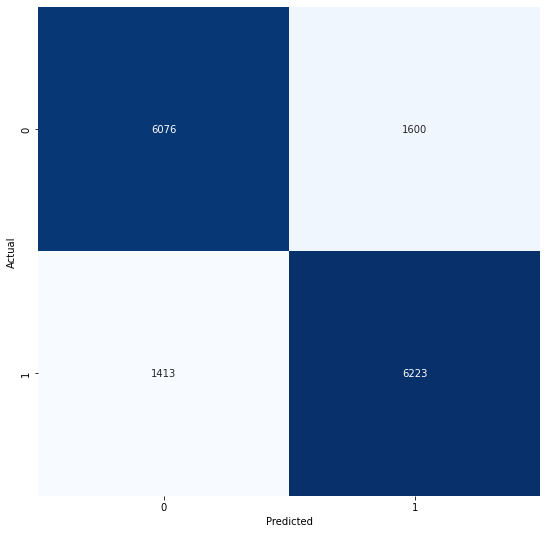

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
prediction = clf_2.predict(X_test_lda)
labels = ['0', '1']
cm=confusion_matrix(Y_test,prediction)
import seaborn as sns
plt.figure(figsize=(9,9))
sns.heatmap(cm, cbar=False, xticklabels=labels, yticklabels=labels, fmt='d', annot=True, cmap=plt.cm.Blues)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Confusion Matrix.png')
plt.show()

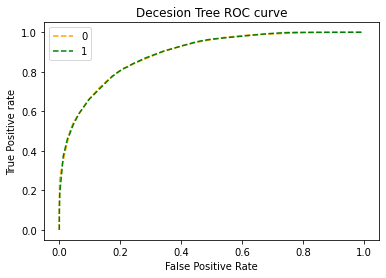

In [ ]:
result_table = pd.DataFrame(columns=['classifiers', 'fpr','tpr','auc'])
y_pred_proba=clf_2.predict_proba(X_test_lda)

fpr = {}
tpr = {}
thresh ={}

n_class = 2

for i in range(n_class):
    fpr[i], tpr[i], thresh[i] = roc_curve(Y_test, y_pred_proba[:,i], pos_label=i)

# plotting
plt.plot(fpr[0], tpr[0], linestyle='--',color='orange', label='0')
plt.plot(fpr[1], tpr[1], linestyle='--',color='green', label='1')
plt.title('Decesion Tree ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.savefig('Binaryclass ROC',dpi=300);

In [ ]:
# 3. Logistic Regression

from sklearn.linear_model import LogisticRegression
clf_3=LogisticRegression(max_iter=200, C=0.01, penalty='l1',solver='liblinear')
clf_3.fit(X_train_lda,Y_train)
y_pred=clf_3.predict(X_test_lda)

In [ ]:
#accuracy in test data
from sklearn.metrics import accuracy_score as score
print('Accuracy')
print(score(Y_test,y_pred)*100)

Accuracy
79.91771159874608


In [ ]:
##precision & recall
from sklearn.metrics import precision_score, recall_score
Precision = precision_score(Y_test,y_pred)
Recall = recall_score(Y_test,y_pred)
print('Recall = ',Recall)
print('Precision = ',Precision)
from sklearn.metrics import f1_score
f1 = f1_score(Y_test,y_pred)
print('F1 = ',f1)
#AUC score
from sklearn.metrics import roc_auc_score
AUC = roc_auc_score(Y_test,y_pred)
print('AUC = ', AUC)

Recall =  0.7951807228915663
Precision =  0.8007384939997363
F1 =  0.7979499310072935
AUC =  0.799166703290494


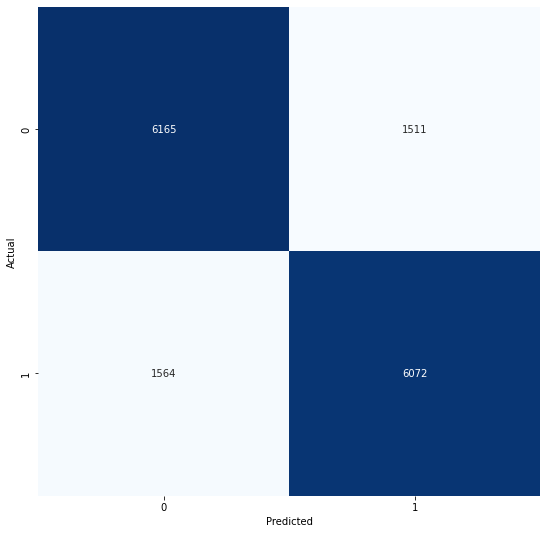

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
prediction = clf_3.predict(X_test_lda)
labels = ['0', '1']
cm=confusion_matrix(Y_test,prediction)
import seaborn as sns
plt.figure(figsize=(9,9))
sns.heatmap(cm, cbar=False, xticklabels=labels, yticklabels=labels, fmt='d', annot=True, cmap=plt.cm.Blues)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Confusion Matrix.png')
plt.show()

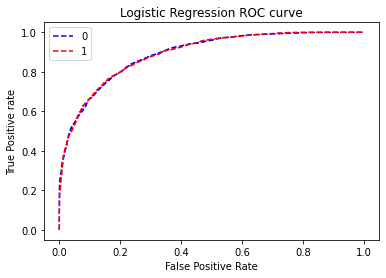

In [ ]:
result_table = pd.DataFrame(columns=['classifiers', 'fpr','tpr','auc'])
y_pred_proba=clf_3.predict_proba(X_test_lda)

fpr = {}
tpr = {}
thresh ={}

n_class = 2

for i in range(n_class):
    fpr[i], tpr[i], thresh[i] = roc_curve(Y_test, y_pred_proba[:,i], pos_label=i)

# plotting
plt.plot(fpr[0], tpr[0], linestyle='--',color='blue', label='0')
plt.plot(fpr[1], tpr[1], linestyle='--',color='red', label='1')
plt.title('Logistic Regression ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.savefig('Multiclass ROC',dpi=300);

In [ ]:
# 4. Random Forest

from sklearn.ensemble import RandomForestClassifier
clf_4= RandomForestClassifier(n_estimators=100,max_depth=10, random_state=7)
clf_4.fit(X_train_lda,Y_train)
y_pred=clf_4.predict(X_test_lda)

In [ ]:
#accuracy in test data
from sklearn.metrics import accuracy_score as score
print('Accuracy')
print(score(Y_test,y_pred)*100)

Accuracy
80.64263322884013


In [ ]:
##precision & recall
from sklearn.metrics import precision_score, recall_score
Precision = precision_score(Y_test,y_pred)
Recall = recall_score(Y_test,y_pred)
print('Recall = ',Recall)
print('Precision = ',Precision)
from sklearn.metrics import f1_score
f1 = f1_score(Y_test,y_pred)
print('F1 = ',f1)
#AUC score
from sklearn.metrics import roc_auc_score
AUC = roc_auc_score(Y_test,y_pred)
print('AUC = ', AUC)

Recall =  0.8103719224724987
Precision =  0.8032191069574247
F1 =  0.8067796610169492
AUC =  0.806436612617177


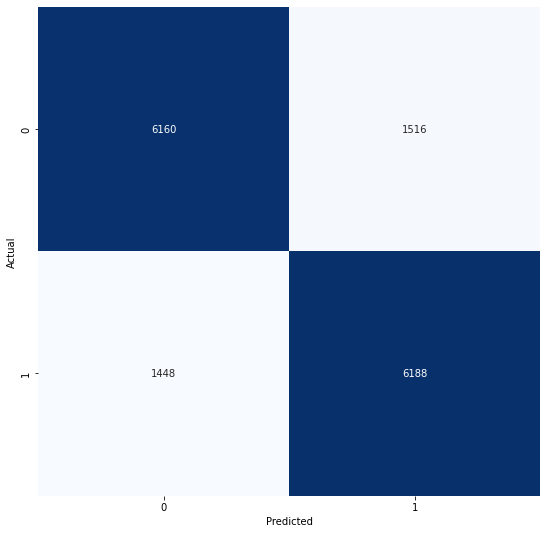

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
prediction = clf_4.predict(X_test_lda)
labels = ['0', '1']
cm=confusion_matrix(Y_test,prediction)
import seaborn as sns
plt.figure(figsize=(9,9))
sns.heatmap(cm, cbar=False, xticklabels=labels, yticklabels=labels, fmt='d', annot=True, cmap=plt.cm.Blues)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Confusion Matrix.png')
plt.show()

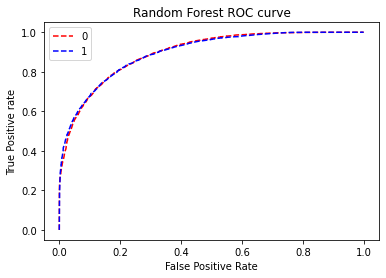

In [ ]:
result_table = pd.DataFrame(columns=['classifiers', 'fpr','tpr','auc'])
y_pred_proba=clf_4.predict_proba(X_test_lda)

fpr = {}
tpr = {}
thresh ={}

n_class = 2

for i in range(n_class):
    fpr[i], tpr[i], thresh[i] = roc_curve(Y_test, y_pred_proba[:,i], pos_label=i)

# plotting
plt.plot(fpr[0], tpr[0], linestyle='--',color='red', label='0')
plt.plot(fpr[1], tpr[1], linestyle='--',color='blue', label='1')
plt.title('Random Forest ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.savefig('Binaryclass',dpi=300);

In [ ]:
# 5. KNN

from sklearn.neighbors import KNeighborsClassifier
clf_5= KNeighborsClassifier(n_neighbors=50)
clf_5.fit(X_train_lda,Y_train)
y_pred=clf_5.predict(X_test_lda)

In [ ]:
#accuracy in test data
from sklearn.metrics import accuracy_score as score
print('Accuracy')
print(score(Y_test,y_pred)*100)

Accuracy
79.78709508881923


In [ ]:
##precision & recall
from sklearn.metrics import precision_score, recall_score
Precision = precision_score(Y_test,y_pred)
Recall = recall_score(Y_test,y_pred)
print('Recall = ',Recall)
print('Precision = ',Precision)
from sklearn.metrics import f1_score
f1 = f1_score(Y_test,y_pred)
print('F1 = ',f1)
#AUC score
from sklearn.metrics import roc_auc_score
AUC = roc_auc_score(Y_test,y_pred)
print('AUC = ', AUC)

Recall =  0.786930330015715
Precision =  0.8036645713521465
F1 =  0.7952094223516177
AUC =  0.797842444841104


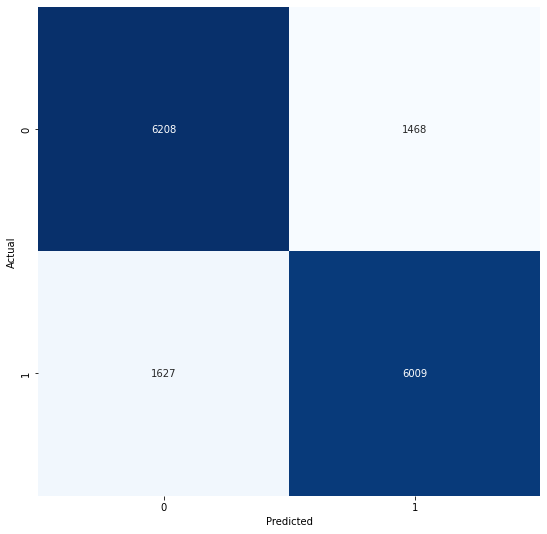

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
prediction = clf_5.predict(X_test_lda)
labels = ['0', '1']
cm=confusion_matrix(Y_test,prediction)
import seaborn as sns
plt.figure(figsize=(9,9))
sns.heatmap(cm, cbar=False, xticklabels=labels, yticklabels=labels, fmt='d', annot=True, cmap=plt.cm.Blues)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Confusion Matrix.png')
plt.show()

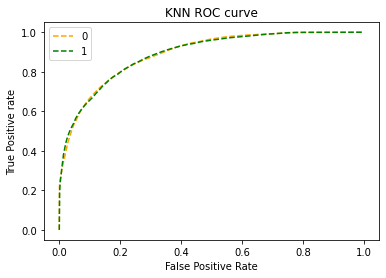

In [ ]:
result_table = pd.DataFrame(columns=['classifiers', 'fpr','tpr','auc'])
y_pred_proba=clf_5.predict_proba(X_test_lda)

fpr = {}
tpr = {}
thresh ={}

n_class = 2

for i in range(n_class):
    fpr[i], tpr[i], thresh[i] = roc_curve(Y_test, y_pred_proba[:,i], pos_label=i)

# plotting
plt.plot(fpr[0], tpr[0], linestyle='--',color='orange', label='0')
plt.plot(fpr[1], tpr[1], linestyle='--',color='green', label='1')
plt.title('KNN ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.savefig('Binaryclass ROC',dpi=300);

In [ ]:
# 6. Naieve bayes

from sklearn.naive_bayes import GaussianNB
clf_6= GaussianNB(var_smoothing=.0001)
clf_6.fit(X_train_lda,Y_train)
y_pred=clf_6.predict(X_test_lda)

In [ ]:
#accuracy in test data
from sklearn.metrics import accuracy_score as score
print('Accuracy')
print(score(Y_test,y_pred)*100)

Accuracy
79.9373040752351


In [ ]:
##precision & recall
from sklearn.metrics import precision_score, recall_score
Precision = precision_score(Y_test,y_pred)
Recall = recall_score(Y_test,y_pred)
print('Recall = ',Recall)
print('Precision = ',Precision)
from sklearn.metrics import f1_score
f1 = f1_score(Y_test,y_pred)
print('F1 = ',f1)
#AUC score
from sklearn.metrics import roc_auc_score
AUC = roc_auc_score(Y_test,y_pred)
print('AUC = ', AUC)

Recall =  0.788239916186485
Precision =  0.8053251271073053
F1 =  0.7966909331568497
AUC =  0.7993440331323254


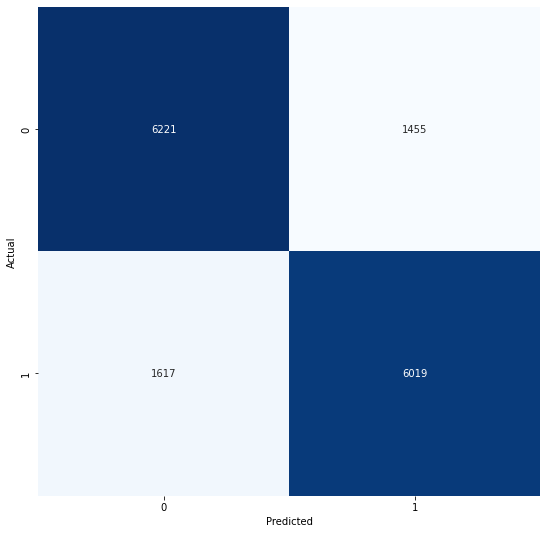

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
prediction = clf_6.predict(X_test_lda)
labels = ['0', '1']
cm=confusion_matrix(Y_test,prediction)
import seaborn as sns
plt.figure(figsize=(9,9))
sns.heatmap(cm, cbar=False, xticklabels=labels, yticklabels=labels, fmt='d', annot=True, cmap=plt.cm.Blues)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Confusion Matrix.png')
plt.show()

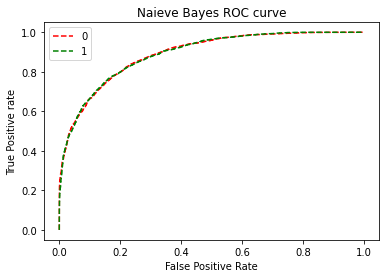

In [ ]:
result_table = pd.DataFrame(columns=['classifiers', 'fpr','tpr','auc'])
y_pred_proba=clf_6.predict_proba(X_test_lda)

fpr = {}
tpr = {}
thresh ={}

n_class = 2

for i in range(n_class):
    fpr[i], tpr[i], thresh[i] = roc_curve(Y_test, y_pred_proba[:,i], pos_label=i)

# plotting
plt.plot(fpr[0], tpr[0], linestyle='--',color='red', label='0')
plt.plot(fpr[1], tpr[1], linestyle='--',color='green', label='1')
plt.title('Naieve Bayes ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')
plt.savefig('Binaryclass',dpi=300);

In [ ]:
from sklearn.ensemble import VotingClassifier
estimators=[]

estimators.append(('SVM', clf_1))
estimators.append(('DT', clf_2))
estimators.append(('LR', clf_3))
estimators.append(('RF', clf_4))
estimators.append(('KNN', clf_5))
estimators.append(('Naieve Bayes', clf_6))


# create the ensemble model
voting_soft = VotingClassifier(estimators, voting='soft')
voting_soft.fit(X_train, Y_train)

VotingClassifier(estimators=[('SVM',
                              SVC(C=0.001, kernel='linear', probability=True,
                                  random_state=7)),
                             ('DT',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=1)),
                             ('LR',
                              LogisticRegression(C=0.01, max_iter=200,
                                                 penalty='l1',
                                                 solver='liblinear')),
                             ('RF',
                              RandomForestClassifier(max_depth=10,
                                                     random_state=7)),
                             ('KNN', KNeighborsClassifier(n_neighbors=50)),
                             ('Naieve Bayes',
                              GaussianNB(var_smoothing=0.0001))],
                 voting='soft')

In [ ]:
#training with softVoting in training data
from sklearn.metrics import accuracy_score
soft_predict_train = voting_soft.predict(X_train)

#get accuracy
soft_accuracy = accuracy_score(Y_train, soft_predict_train)

#print accuracy
print("Accuracy: {0:.4f}".format(soft_accuracy*100))

Accuracy: 88.7164


In [ ]:
# softvoting in testing data
soft_predict_test = voting_soft.predict(X_test)

#get accuracy
soft_accuracy_testdata = accuracy_score(Y_test, soft_predict_test)

#print accuracy
print ("Accuracy: {0:.4f}".format(soft_accuracy_testdata*100))

Accuracy: 87.6959


In [ ]:
##precision & recall for hard
from sklearn.metrics import precision_score, recall_score
Precision = precision_score(Y_test,soft_predict_test)
Recall = recall_score(Y_test,soft_predict_test)
print('Recall = ',Recall)
print('Precision = ',Precision)
from sklearn.metrics import f1_score
f1 = f1_score(Y_test,soft_predict_test)
print('F1 = ',f1)
#AUC score
from sklearn.metrics import roc_auc_score
AUC = roc_auc_score(Y_test,soft_predict_test)
print('AUC = ', AUC)

Recall =  0.8647197485594552
Precision =  0.8858331097397371
F1 =  0.8751491053677933
AUC =  0.8769273573438235


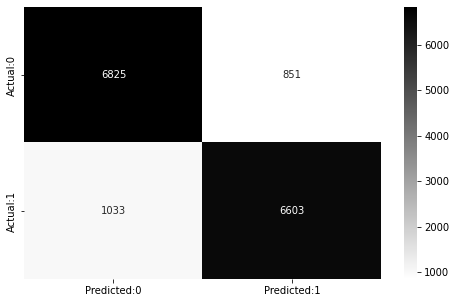

In [ ]:
#confusion matrix for Soft voting
from sklearn.metrics import confusion_matrix
conf_soft=confusion_matrix(Y_test,soft_predict_test)
conf_soft_matrix=pd.DataFrame(data=conf_soft,columns=['Predicted:0','Predicted:1'],index=['Actual:0','Actual:1'])
plt.figure(figsize = (8,5))
sns.heatmap(conf_soft_matrix, annot=True,fmt='d',cmap="binary")

In [ ]:
from sklearn.base import BaseEstimator
from sklearn.base import ClassifierMixin
from sklearn.preprocessing import LabelEncoder
import six
import sys
sys.modules['sklearn.externals.six'] = six
from sklearn.base import clone
from sklearn.pipeline import _name_estimators
import numpy as np
import operator

class MajorityVoteClassifier(BaseEstimator,
                             ClassifierMixin):

    def __init__(self, classifiers, vote='classlabel', weights=None):

        self.classifiers = classifiers
        self.named_classifiers = {key: value for key, value
                                  in _name_estimators(classifiers)}
        self.vote = vote
        self.weights = weights

    def fit(self, X, y):

        if self.vote not in ('probability', 'classlabel'):
            raise ValueError("vote must be 'probability' or 'classlabel'"
                             "; got (vote=%r)"
                             % self.vote)

        if self.weights and len(self.weights) != len(self.classifiers):
            raise ValueError('Number of classifiers and weights must be equal'
                             '; got %d weights, %d classifiers'
                             % (len(self.weights), len(self.classifiers)))

        # Use LabelEncoder to ensure class labels start with 0, which
        # is important for np.argmax call in self.predict
        self.lablenc_ = LabelEncoder()
        self.lablenc_.fit(y)
        self.classes_ = self.lablenc_.classes_
        self.classifiers_ = []
        for clf in self.classifiers:
            fitted_clf = clone(clf).fit(X, self.lablenc_.transform(y))
            self.classifiers_.append(fitted_clf)
        return self
    def predict(self, X):

        if self.vote == 'probability':
            maj_vote = np.argmax(self.predict_proba(X), axis=1)
        else:  # 'classlabel' vote

            #  Collect results from clf.predict calls
            predictions = np.asarray([clf.predict(X)
                                      for clf in self.classifiers_]).T

            maj_vote = np.apply_along_axis(
                                      lambda x:
                                      np.argmax(np.bincount(x,
                                                weights=self.weights)),
                                      axis=1,
                                      arr=predictions)
        maj_vote = self.lablenc_.inverse_transform(maj_vote)
        return maj_vote

    def predict_proba(self, X):

        probas = np.asarray([clf.predict_proba(X)
                             for clf in self.classifiers_])
        avg_proba = np.average(probas, axis=0, weights=self.weights)
        return avg_proba

    def get_params(self, deep=True):
        """ Get classifier parameter names for GridSearch"""
        if not deep:
            return super(MajorityVoteClassifier, self).get_params(deep=False)
        else:
            out = self.named_classifiers.copy()
            for name, step in six.iteritems(self.named_classifiers):
                for key, value in six.iteritems(step.get_params(deep=True)):
                    out['%s__%s' % (name, key)] = value
            return out

In [ ]:
# Majority Rule (Soft) Voting
from sklearn.model_selection import cross_val_score
from mlxtend.classifier import EnsembleVoteClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.datasets import make_classification
mv_clf = MajorityVoteClassifier(classifiers=[clf_1, clf_2, clf_3, clf_4, clf_5, clf_6])

clf_lab = ['SVM','DT','LR','Random Forest', 'KNN','Naieve Bayes']
all_clf = [clf_1, clf_2, clf_3, clf_4, clf_5, clf_6, mv_clf]

for clf, label in zip(all_clf, clf_lab):
    scores = cross_val_score(estimator=clf,
                             X=X_train,
                             y=Y_train,
                             cv=10,
                             scoring='roc_auc')
    print("ROC AUC: %0.2f (+/- %0.2f) [%s]"
          % (scores.mean(), scores.std(), label))

ROC AUC: 0.89 (+/- 0.00) [SVM]
ROC AUC: 0.86 (+/- 0.00) [DT]
ROC AUC: 0.89 (+/- 0.00) [LR]
ROC AUC: 0.99 (+/- 0.00) [Random Forest]
ROC AUC: 0.98 (+/- 0.00) [KNN]
ROC AUC: 0.92 (+/- 0.00) [Naieve Bayes]


Text(0.5, 1.0, 'ROC Curves for Smart Grid Stability  Predicting Classifiers')

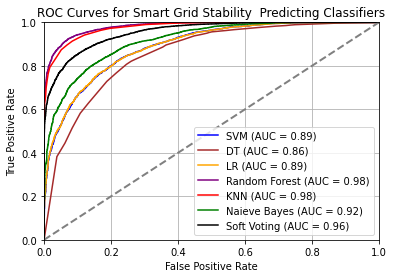

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

all_clf = [clf_1, clf_2, clf_3, clf_4, clf_5,clf_6, mv_clf]
clf_labels = ['SVM','DT','LR','Random Forest', 'KNN','Naieve Bayes', 'Soft Voting']
colors = ['blue', 'brown', 'orange','purple', 'red', 'green' ,'black']
linestyles = ['-', '-', '-', '-', '-', '-','-']
for clf, label, clr, ls \
        in zip(all_clf,
               clf_labels, colors, linestyles):

    # assuming the label of the positive class is 1
    y_pred = clf.fit(X_train,
                     Y_train).predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true=Y_test,
                                     y_score=y_pred)
    roc_auc = auc(x=fpr, y=tpr)
    plt.plot(fpr, tpr,
             color=clr,
             linestyle=ls,
             label='%s (AUC = %0.2f)' % (label, roc_auc))

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1],
         linestyle='--',
         color='gray',
         linewidth=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.grid(True)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Smart Grid Stability  Predicting Classifiers')